# 00-eda-airbnb-ny

**1. CARGA DEL DATASET**

In [1]:
# IMPORTO LAS LIBRERÍAS NECESARIAS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import chi2, SelectKBest, f_regression
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

In [2]:
# CARGO LOS DATOS
total_data = pd.read_csv('/workspaces/alemantellini-machine-learning/data/raw/AB_NYC_2019.csv')
total_data

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaN,NaN,2,9
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaN,NaN,2,36
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaN,NaN,1,27
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaN,NaN,6,2


In [3]:
total_data.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [4]:
total_data.tail()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaN,NaN,2,9
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaN,NaN,2,36
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaN,NaN,1,27
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaN,NaN,6,2
48894,36487245,Trendy duplex in the very heart of Hell's Kitchen,68119814,Christophe,Manhattan,Hell's Kitchen,40.76404,-73.98933,Private room,90,7,0,NaN,NaN,1,23


In [5]:
total_data.shape

(48895, 16)

In [6]:
total_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

In [7]:
total_data.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='str')

- El dataset contiene 48.895 filas y 16 columnas relacionadas con alquileres de Airbnb en Nueva York en 2019.
- Incluye variables de ubicación, precio, tipo de habitación, disponibilidad y reseñas.

In [8]:
# TODOS LOS VALORES FALTANTES DEL DATAFRAME
total_data.isna().sum().sum()

np.int64(20141)

In [9]:
# CUENTO LOS VALORES NULOS PARA CADA COLUMNA
total_data.isna().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [10]:
(total_data.isna().sum() / len(total_data) * 100).sort_values(ascending=False)

last_review                       20.558339
reviews_per_month                 20.558339
host_name                          0.042949
name                               0.032723
neighbourhood_group                0.000000
neighbourhood                      0.000000
id                                 0.000000
host_id                            0.000000
longitude                          0.000000
latitude                           0.000000
room_type                          0.000000
price                              0.000000
number_of_reviews                  0.000000
minimum_nights                     0.000000
calculated_host_listings_count     0.000000
availability_365                   0.000000
dtype: float64

In [11]:
total_data.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [12]:
# POSIBLES DATOS CATEGÓRICOS
total_data.select_dtypes(include=['object']).columns

/tmp/ipykernel_26833/1623080498.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  total_data.select_dtypes(include=['object']).columns


Index(['name', 'host_name', 'neighbourhood_group', 'neighbourhood',
       'room_type', 'last_review'],
      dtype='str')

**2. LIMPIEZA INICIAL**

In [13]:
total_data['id'].duplicated().sum()

np.int64(0)

In [14]:
total_data[total_data['id'].duplicated() == True]

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365


In [15]:
total_data['id'].value_counts()

id
2539        1
2595        1
3647        1
3831        1
5022        1
           ..
36484665    1
36485057    1
36485431    1
36485609    1
36487245    1
Name: count, Length: 48895, dtype: int64

In [16]:
total_data = total_data.drop_duplicates(subset=total_data.columns.difference(['id']))
print(total_data.shape)
total_data.head()

(48895, 16)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [17]:
# ELIMINO LAS COLUMNAS QUE DECIDÍ ELIMINAR
total_data.drop(columns=['last_review','reviews_per_month','host_name','name', 'latitude', 'longitude'], inplace=True)
total_data = total_data.dropna().reset_index(drop=True)
total_data.head()

,id,host_id,neighbourhood_group,neighbourhood,room_type,price,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365
0,2539,2787,Brooklyn,Kensington,Private room,149,1,9,6,365
1,2595,2845,Manhattan,Midtown,Entire home/apt,225,1,45,2,355
2,3647,4632,Manhattan,Harlem,Private room,150,3,0,1,365
3,3831,4869,Brooklyn,Clinton Hill,Entire home/apt,89,1,270,1,194
4,5022,7192,Manhattan,East Harlem,Entire home/apt,80,10,9,1,0


In [18]:
total_data.shape

(48895, 10)

In [19]:
total_data.isna().sum()

id                                0
host_id                           0
neighbourhood_group               0
neighbourhood                     0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64

In [20]:
total_data.columns

Index(['id', 'host_id', 'neighbourhood_group', 'neighbourhood', 'room_type',
       'price', 'minimum_nights', 'number_of_reviews',
       'calculated_host_listings_count', 'availability_365'],
      dtype='str')

- Las variables 'last_review' y 'reviews_per_month' tenían muchos valores nulos. Para evitar problemas en el análisis, decidí eliminar esas columnas.
- Se eliminaron 'longitude' y 'latitude' porque, en este proyecto, no era necesario realizar un análisis de grupos geográficos.
- Las variables 'host_name' y 'name' se excluyeron porque no aportan información predictiva.

**3. ANÁLISIS DE VARIABLES**

- Variables categóricas: 'id', 'host_id', 'neighbourhood_group', 'neighbourhood', 'room_type', 'availability_365'
- Variables numéricas: 'price', 'minimum_nights', 'number_of_reviews', 'calculated_host_listings_count'
- Variables eliminadas: 'last_review','reviews_per_month','host_name','name', 'latitude', 'longitude'

**Variables categóricas**

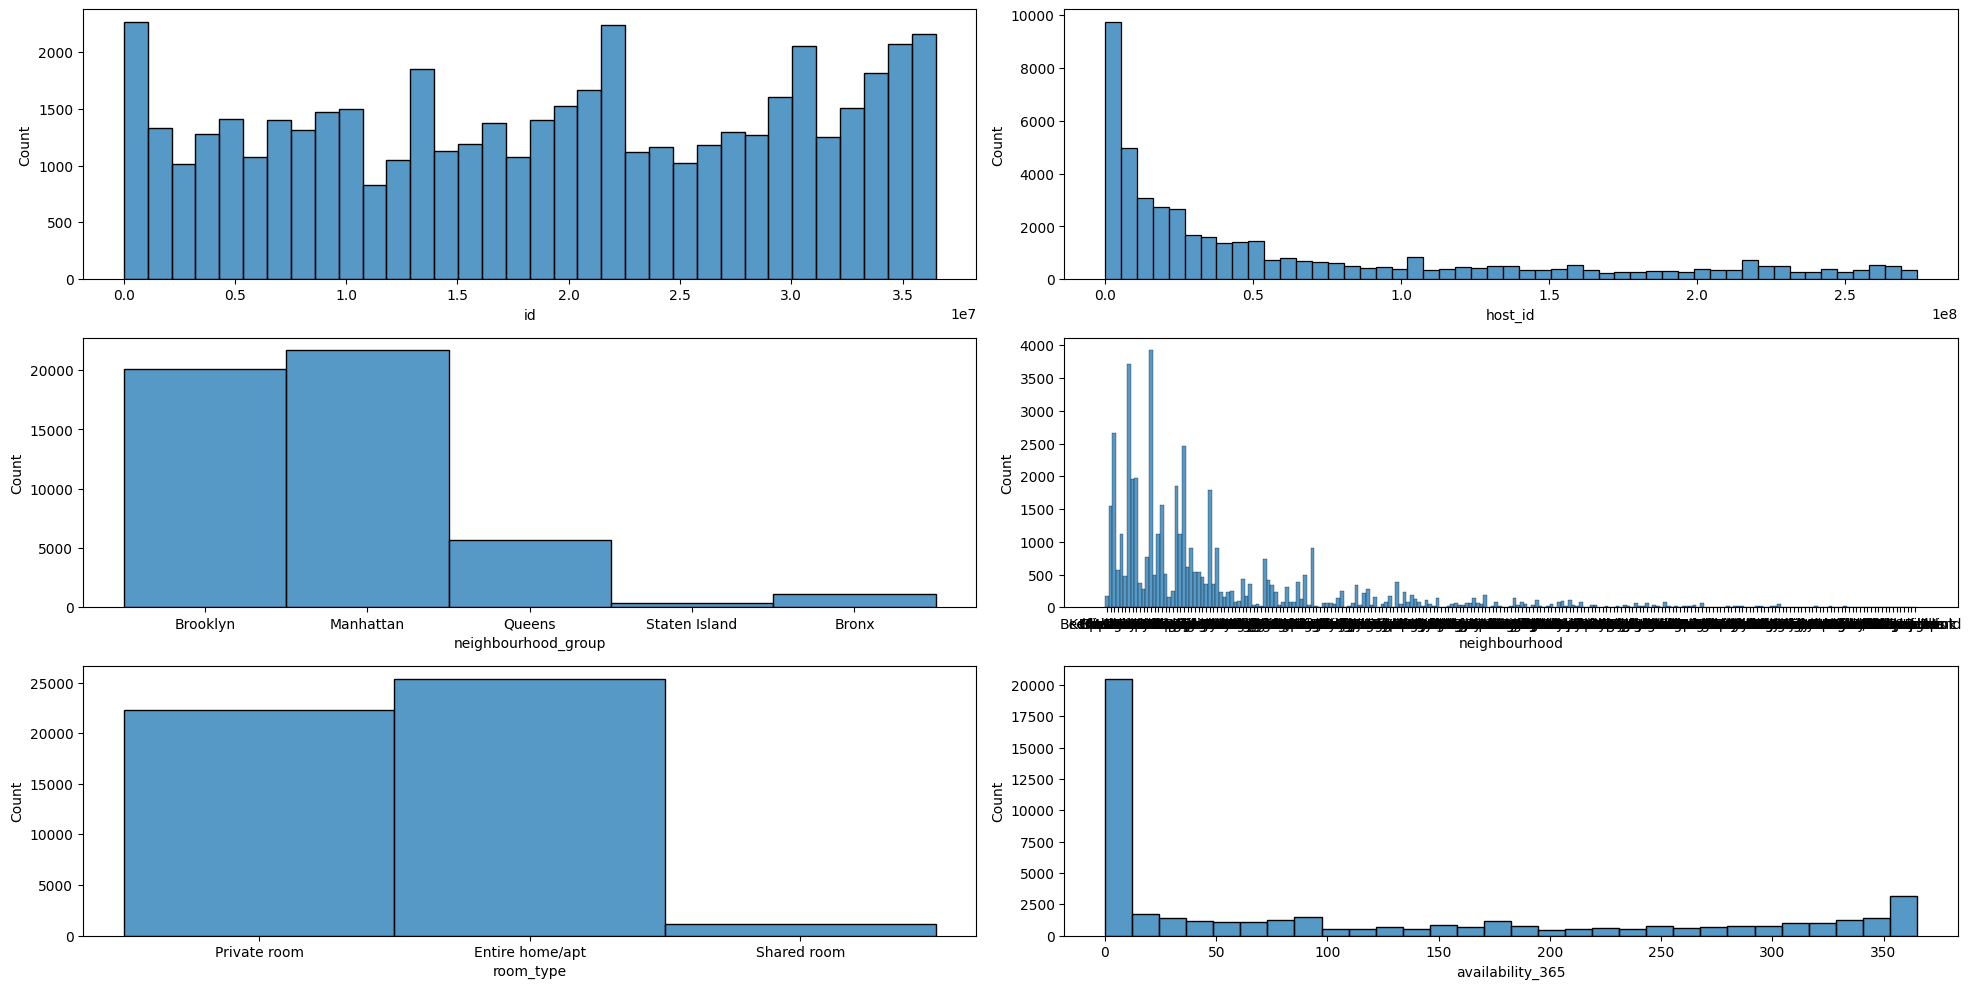

In [21]:
# HISTOGRA MÚLTIPLE
fig, axis = plt.subplots(3, 2, figsize=(20, 10))

sns.histplot(data=total_data, x='id', ax=axis[0,0])
sns.histplot(data=total_data, x='host_id', ax=axis[0,1])

sns.histplot(data=total_data, x='neighbourhood_group', ax=axis[1,0])
sns.histplot(data=total_data, x='neighbourhood', ax=axis[1,1])

sns.histplot(data=total_data, x='room_type', ax=axis[2,0])
sns.histplot(data=total_data, x='availability_365', ax=axis[2,1])

plt.tight_layout()
plt.show()

**Variables numéricas**

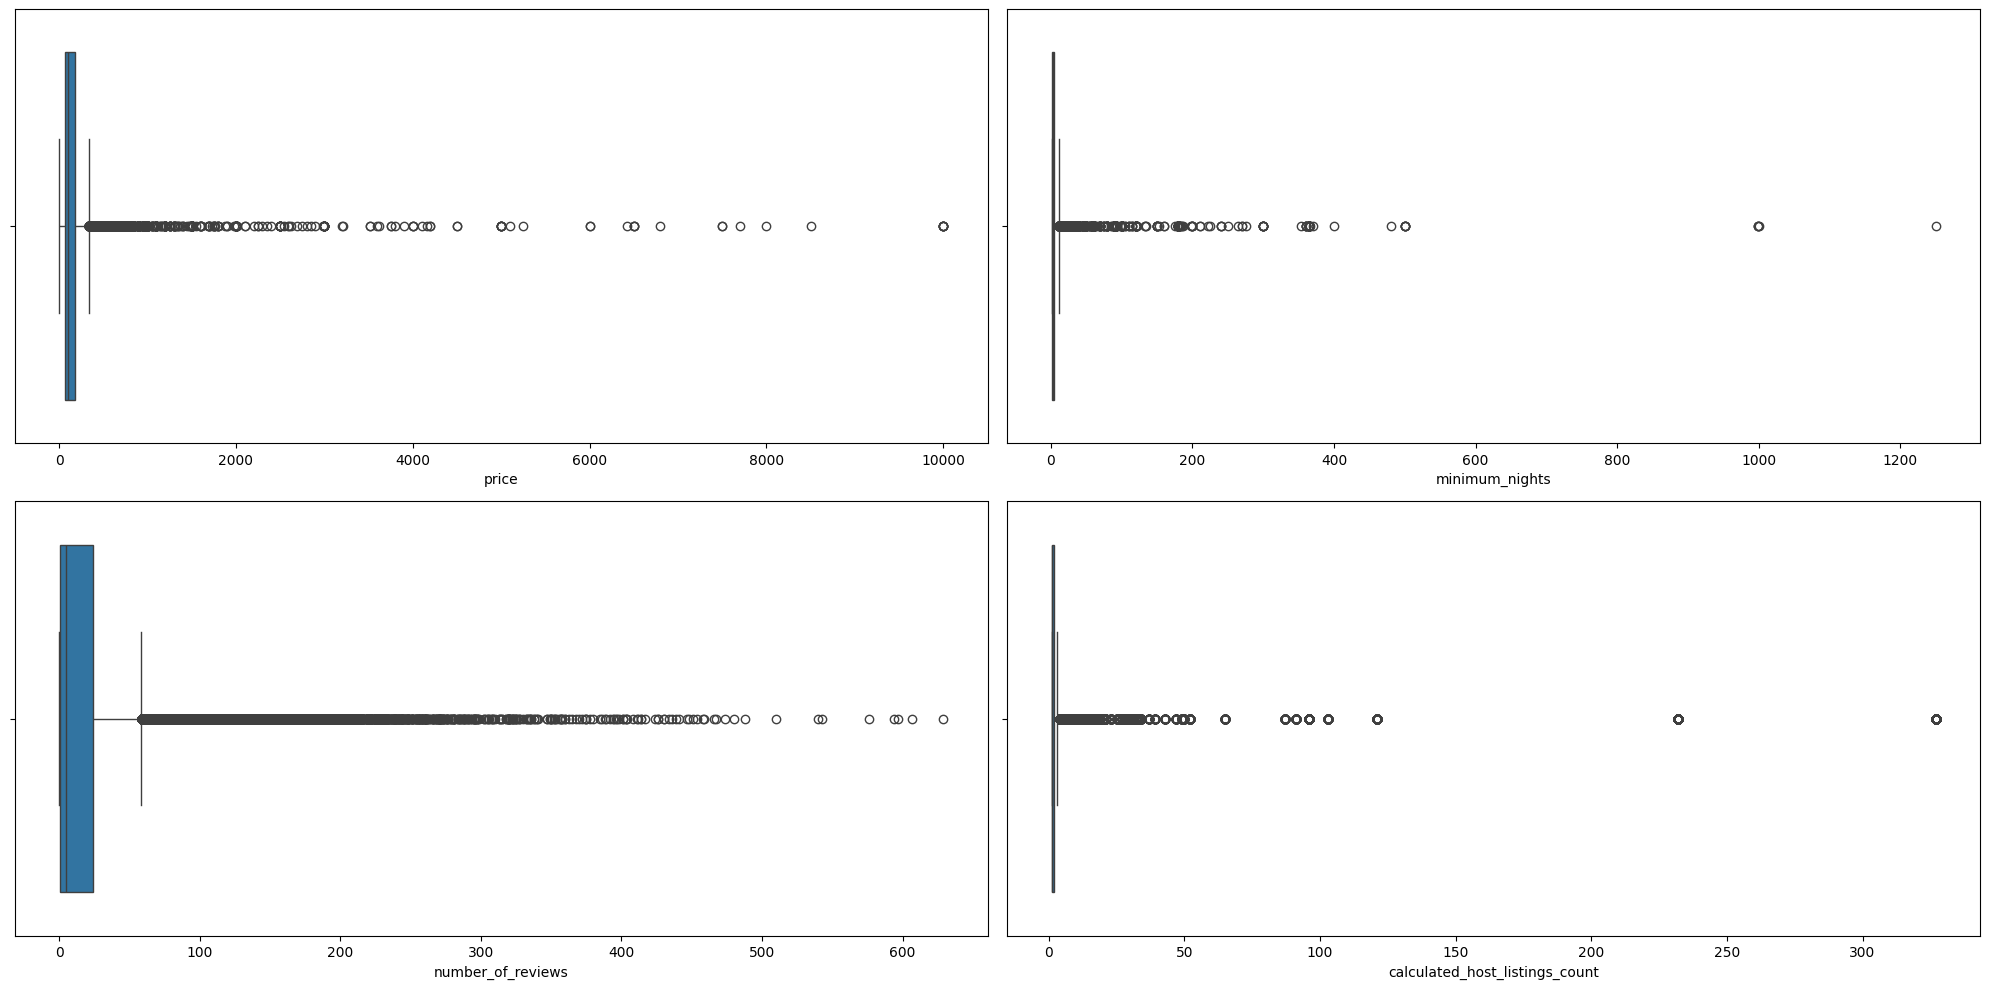

In [22]:
fig, axis = plt.subplots(2, 2, figsize = (20, 10))

sns.boxplot(ax = axis[0, 0], x = total_data["price"])
sns.boxplot(ax = axis[0, 1], x = total_data["minimum_nights"])
sns.boxplot(ax = axis[1, 0], x = total_data["number_of_reviews"])
sns.boxplot(ax = axis[1, 1], x = total_data["calculated_host_listings_count"])

plt.tight_layout()
plt.show()


**4. RELACIONES ENTRE VARIABLES**

**Análisis numérico-numérico**

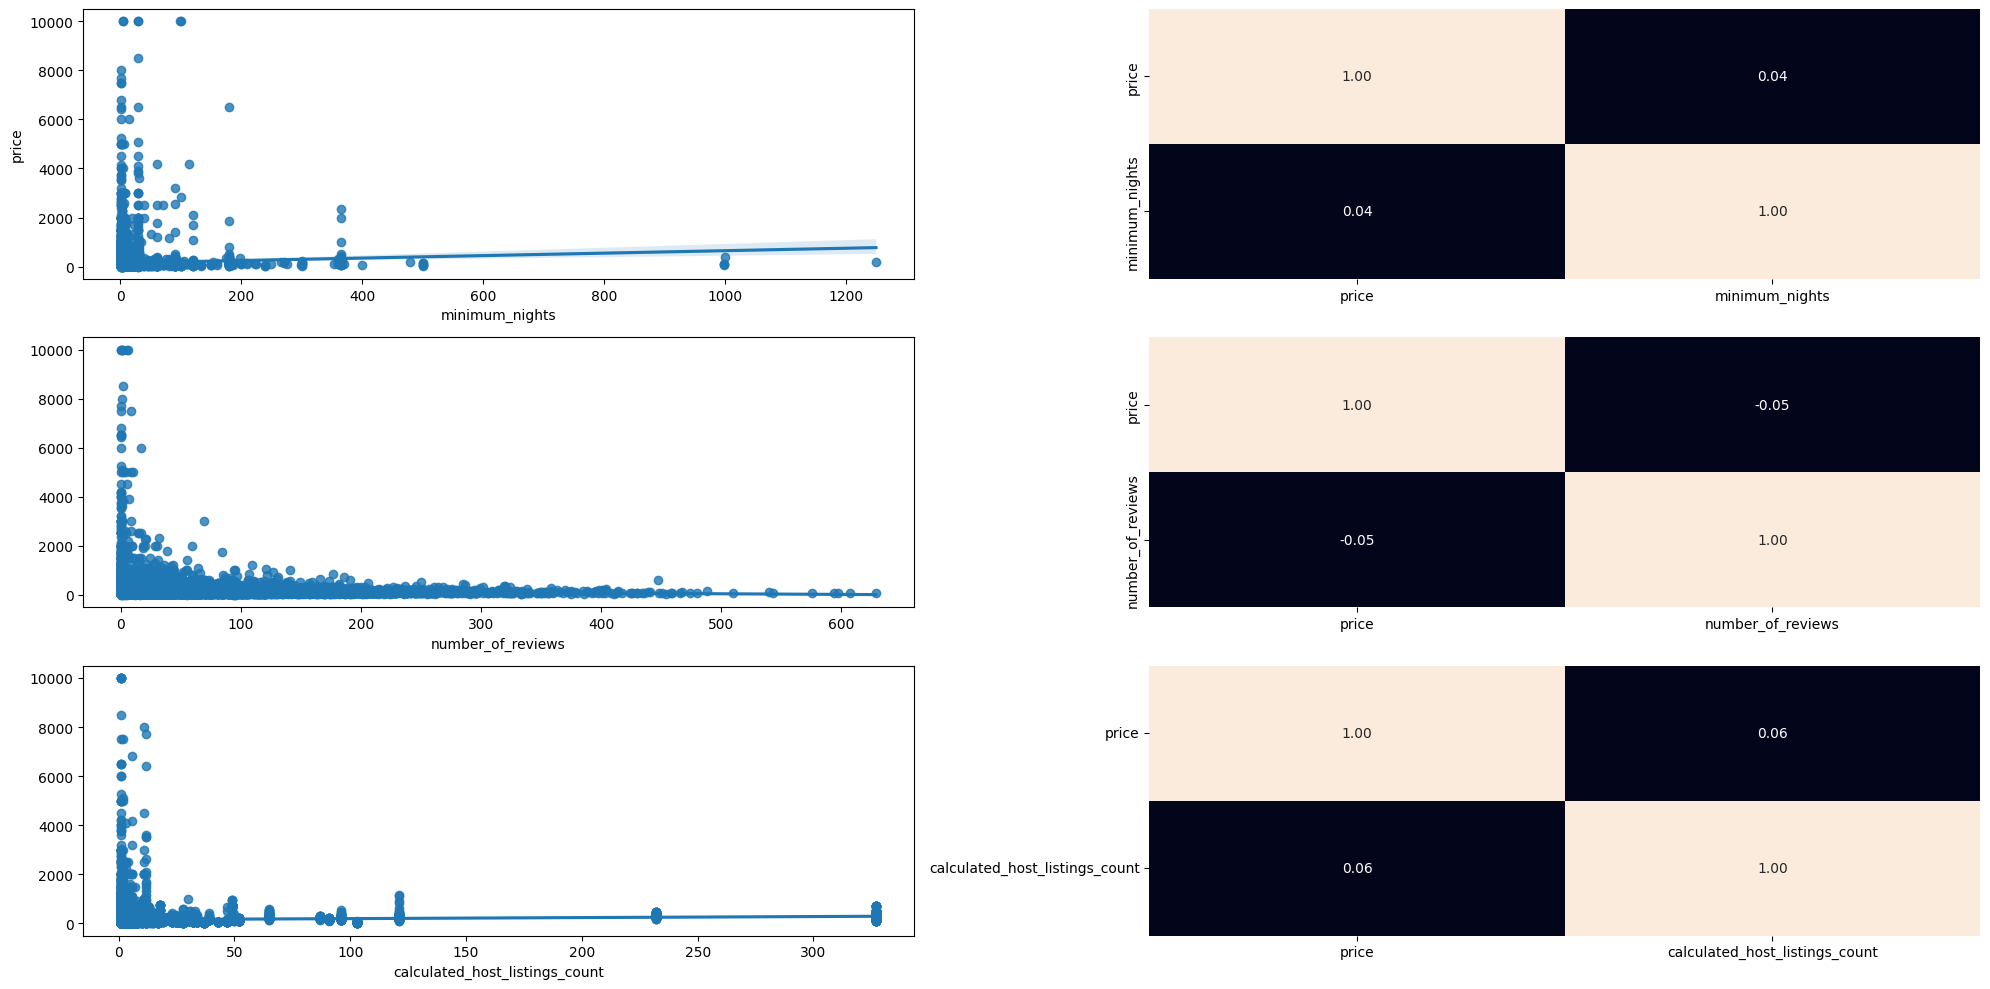

In [23]:
fig, axis = plt.subplots(3, 2, figsize=(20, 10))

# CREO UN DIAGRAMA DE DISPERSIÓN MÚLTIPLE
sns.regplot(ax = axis[0, 0], data = total_data, x = "minimum_nights", y = "price")
sns.heatmap(total_data[["price", "minimum_nights"]].corr(), 
            annot = True, fmt = ".2f", ax = axis[0, 1], cbar = False)

sns.regplot(ax = axis[1, 0], data = total_data, x = "number_of_reviews", y = "price").set(ylabel = None)
sns.heatmap(total_data[["price", "number_of_reviews"]].corr(), 
            annot = True, fmt = ".2f", ax = axis[1, 1], cbar = False)

sns.regplot(ax = axis[2, 0], data = total_data, x = "calculated_host_listings_count", y = "price").set(ylabel = None)
sns.heatmap(total_data[["price", "calculated_host_listings_count"]].corr(), 
            annot = True, fmt = ".2f", ax = axis[2, 1], cbar = False)

plt.tight_layout()
plt.show()

- No existe una relación fuerte entre el precio y el número mínimo de noches.
- No existe una relación fuerte entre el precio y el número de reseñas.

**Análisis categórico-categórico**

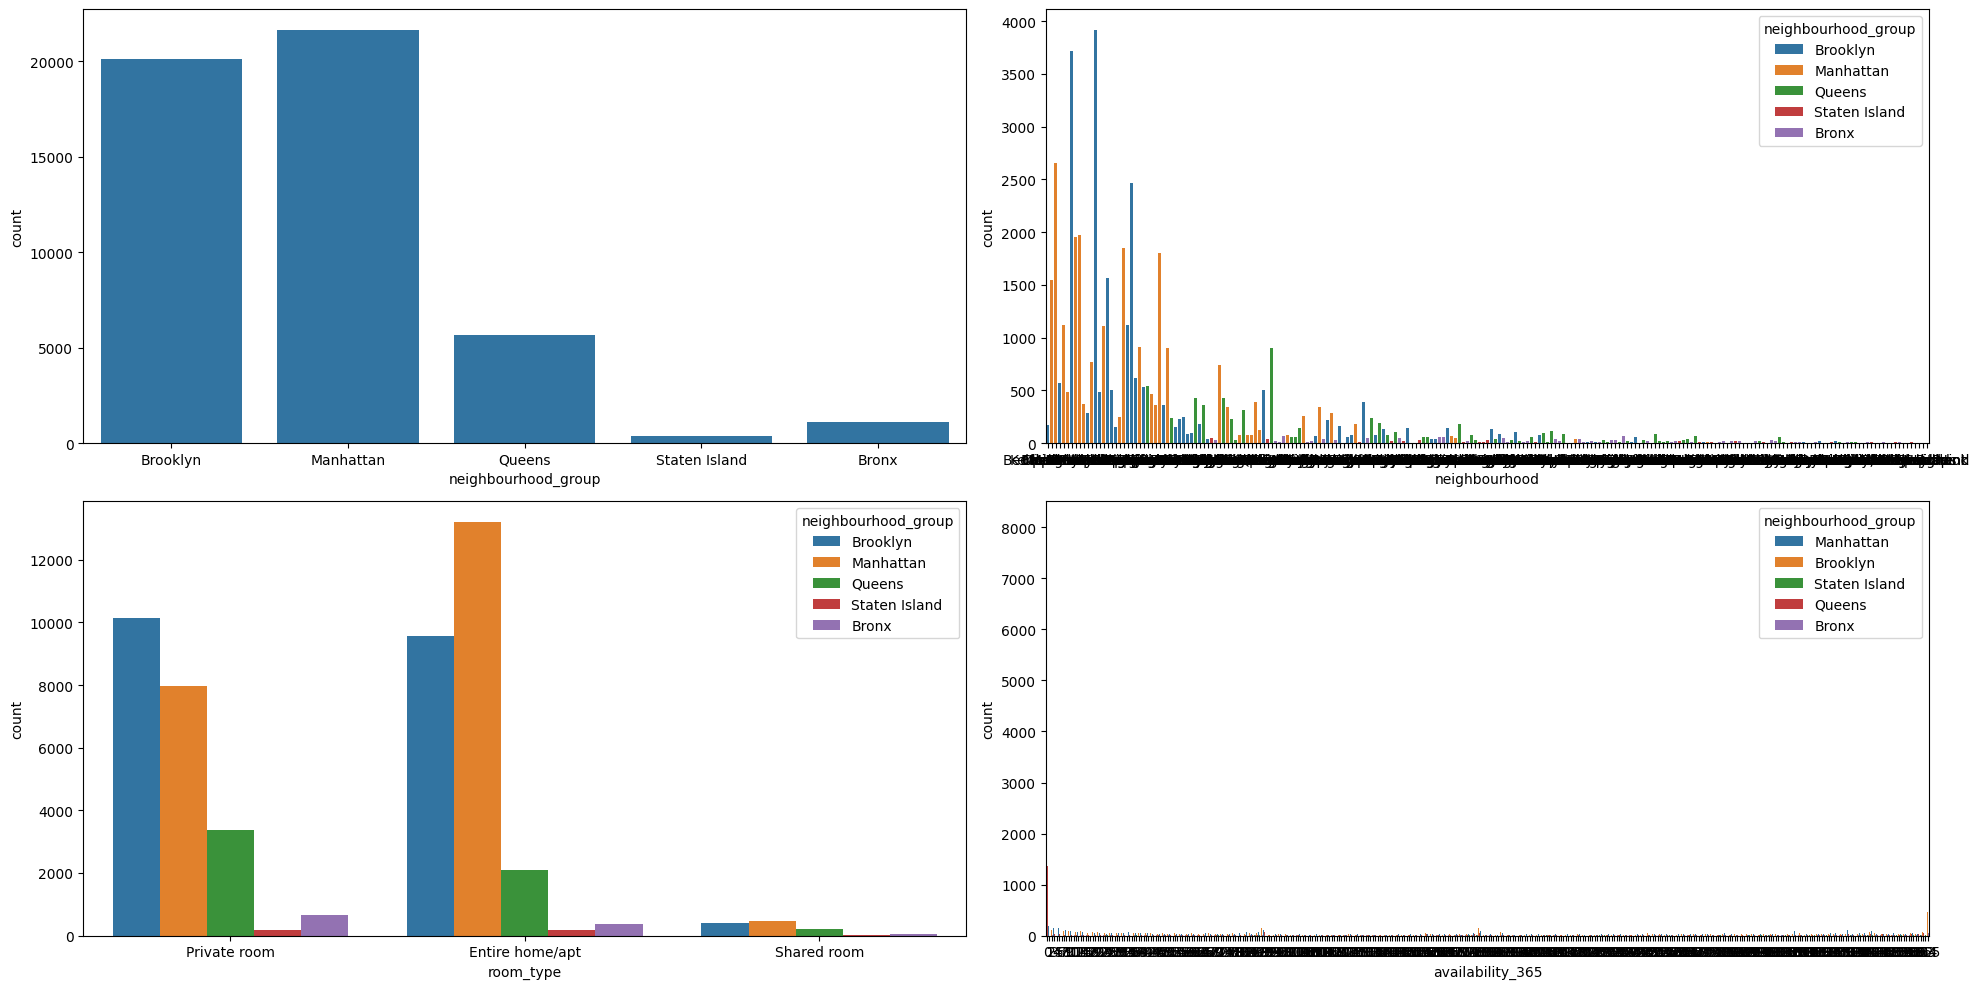

In [24]:
fig, axis = plt.subplots(2, 2, figsize=(20, 10))

# CREO UN DIAGRAMA DE DISPERSIÓN MÚLTIPLE
sns.countplot(ax=axis[0,0], data=total_data, x="neighbourhood_group")
sns.countplot(ax=axis[0,1], data=total_data, x="neighbourhood", hue="neighbourhood_group")
sns.countplot(ax=axis[1,0], data=total_data, x="room_type", hue="neighbourhood_group")
sns.countplot(ax=axis[1,1], data=total_data, x="availability_365", hue="neighbourhood_group")

plt.tight_layout()
plt.show()

- Manhattan y Brooklyn concentran la mayor cantidad de alojamientos.
- Manhattan es el barrio con más sitios para alquilar. También es el barrio que tiene más viviendas completas ("entire home/apt").
- Brooklyn es el segundo barrio que más sitios tiene para alquilar. También es el barrio que tiene más habitaciones privadas.
- Staten Island tiene muy poca presencia en Airbnb.
- La mayoría de los alojamientos corresponden a viviendas completas o habitaciones privadas.

([0, 1, 2, 3, 4],
 [Text(0, 0, 'Brooklyn'),
  Text(1, 0, 'Manhattan'),
  Text(2, 0, 'Queens'),
  Text(3, 0, 'Staten Island'),
  Text(4, 0, 'Bronx')])

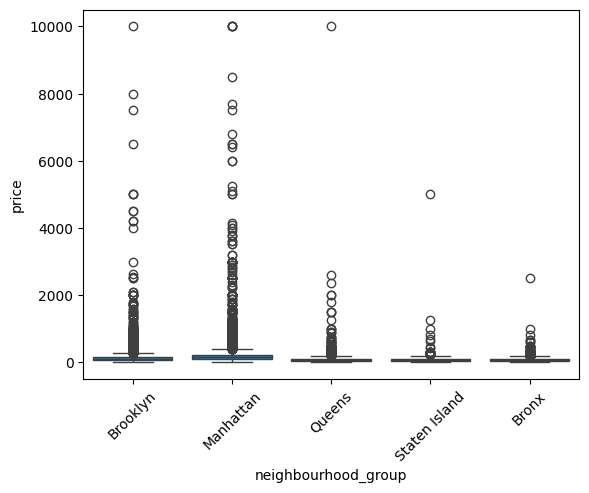

In [25]:
# PRECIO POR BARRIO
sns.boxplot(x="neighbourhood_group", y="price", data=total_data)
plt.xticks(rotation=45)

- Manhattan presenta los precios más elevados.

<Axes: xlabel='room_type', ylabel='price'>

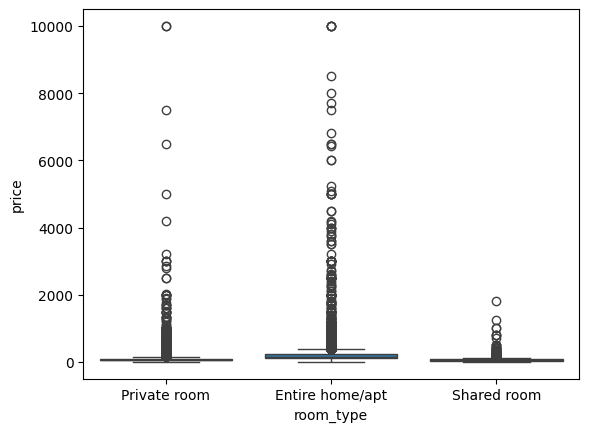

In [26]:
# PRECIO POR TIPO DE HABITACIÓN
sns.boxplot(x="room_type", y="price", data=total_data)

Las viviendas completas presentan precios superiores.

**Análisis numérico-categórico**

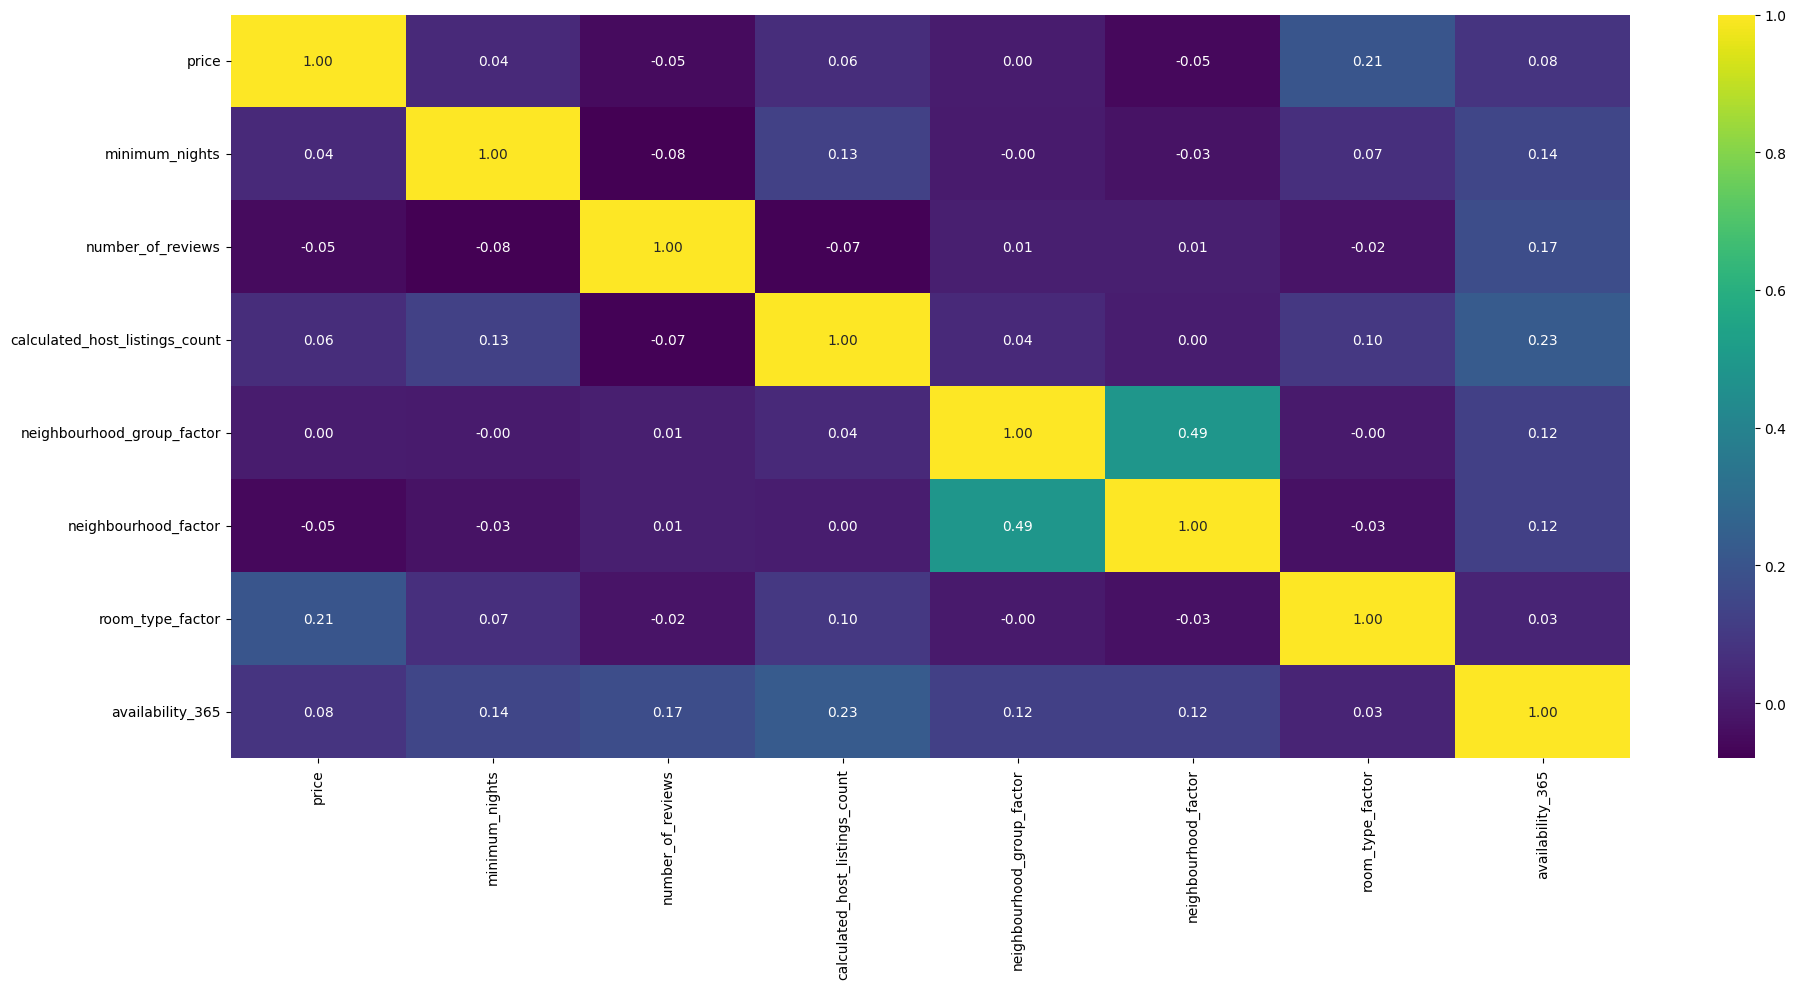

In [27]:
# Primero, creo las columnas factorizadas si no existen
if 'neighbourhood_group_factor' not in total_data.columns:
    total_data['neighbourhood_group_factor'] = pd.factorize(total_data['neighbourhood_group'])[0]
if 'neighbourhood_factor' not in total_data.columns:
    total_data['neighbourhood_factor'] = pd.factorize(total_data['neighbourhood'])[0]
if 'room_type_factor' not in total_data.columns:
    total_data['room_type_factor'] = pd.factorize(total_data['room_type'])[0]

cols_num = ['price', 'minimum_nights', 'number_of_reviews', 'calculated_host_listings_count',
            'neighbourhood_group_factor', 'neighbourhood_factor', 'room_type_factor', 'availability_365']

fig, ax= plt.subplots(figsize=(20, 10))
sns.heatmap(total_data[cols_num].corr(method="pearson"),
            annot=True, fmt=".2f", cmap="viridis", ax=ax)
plt.tight_layout()
plt.show()

Los anfitriones con más listings tienden a tener más disponibilidad. Además de eso, hay una correlación muy baja entre todos los datos.

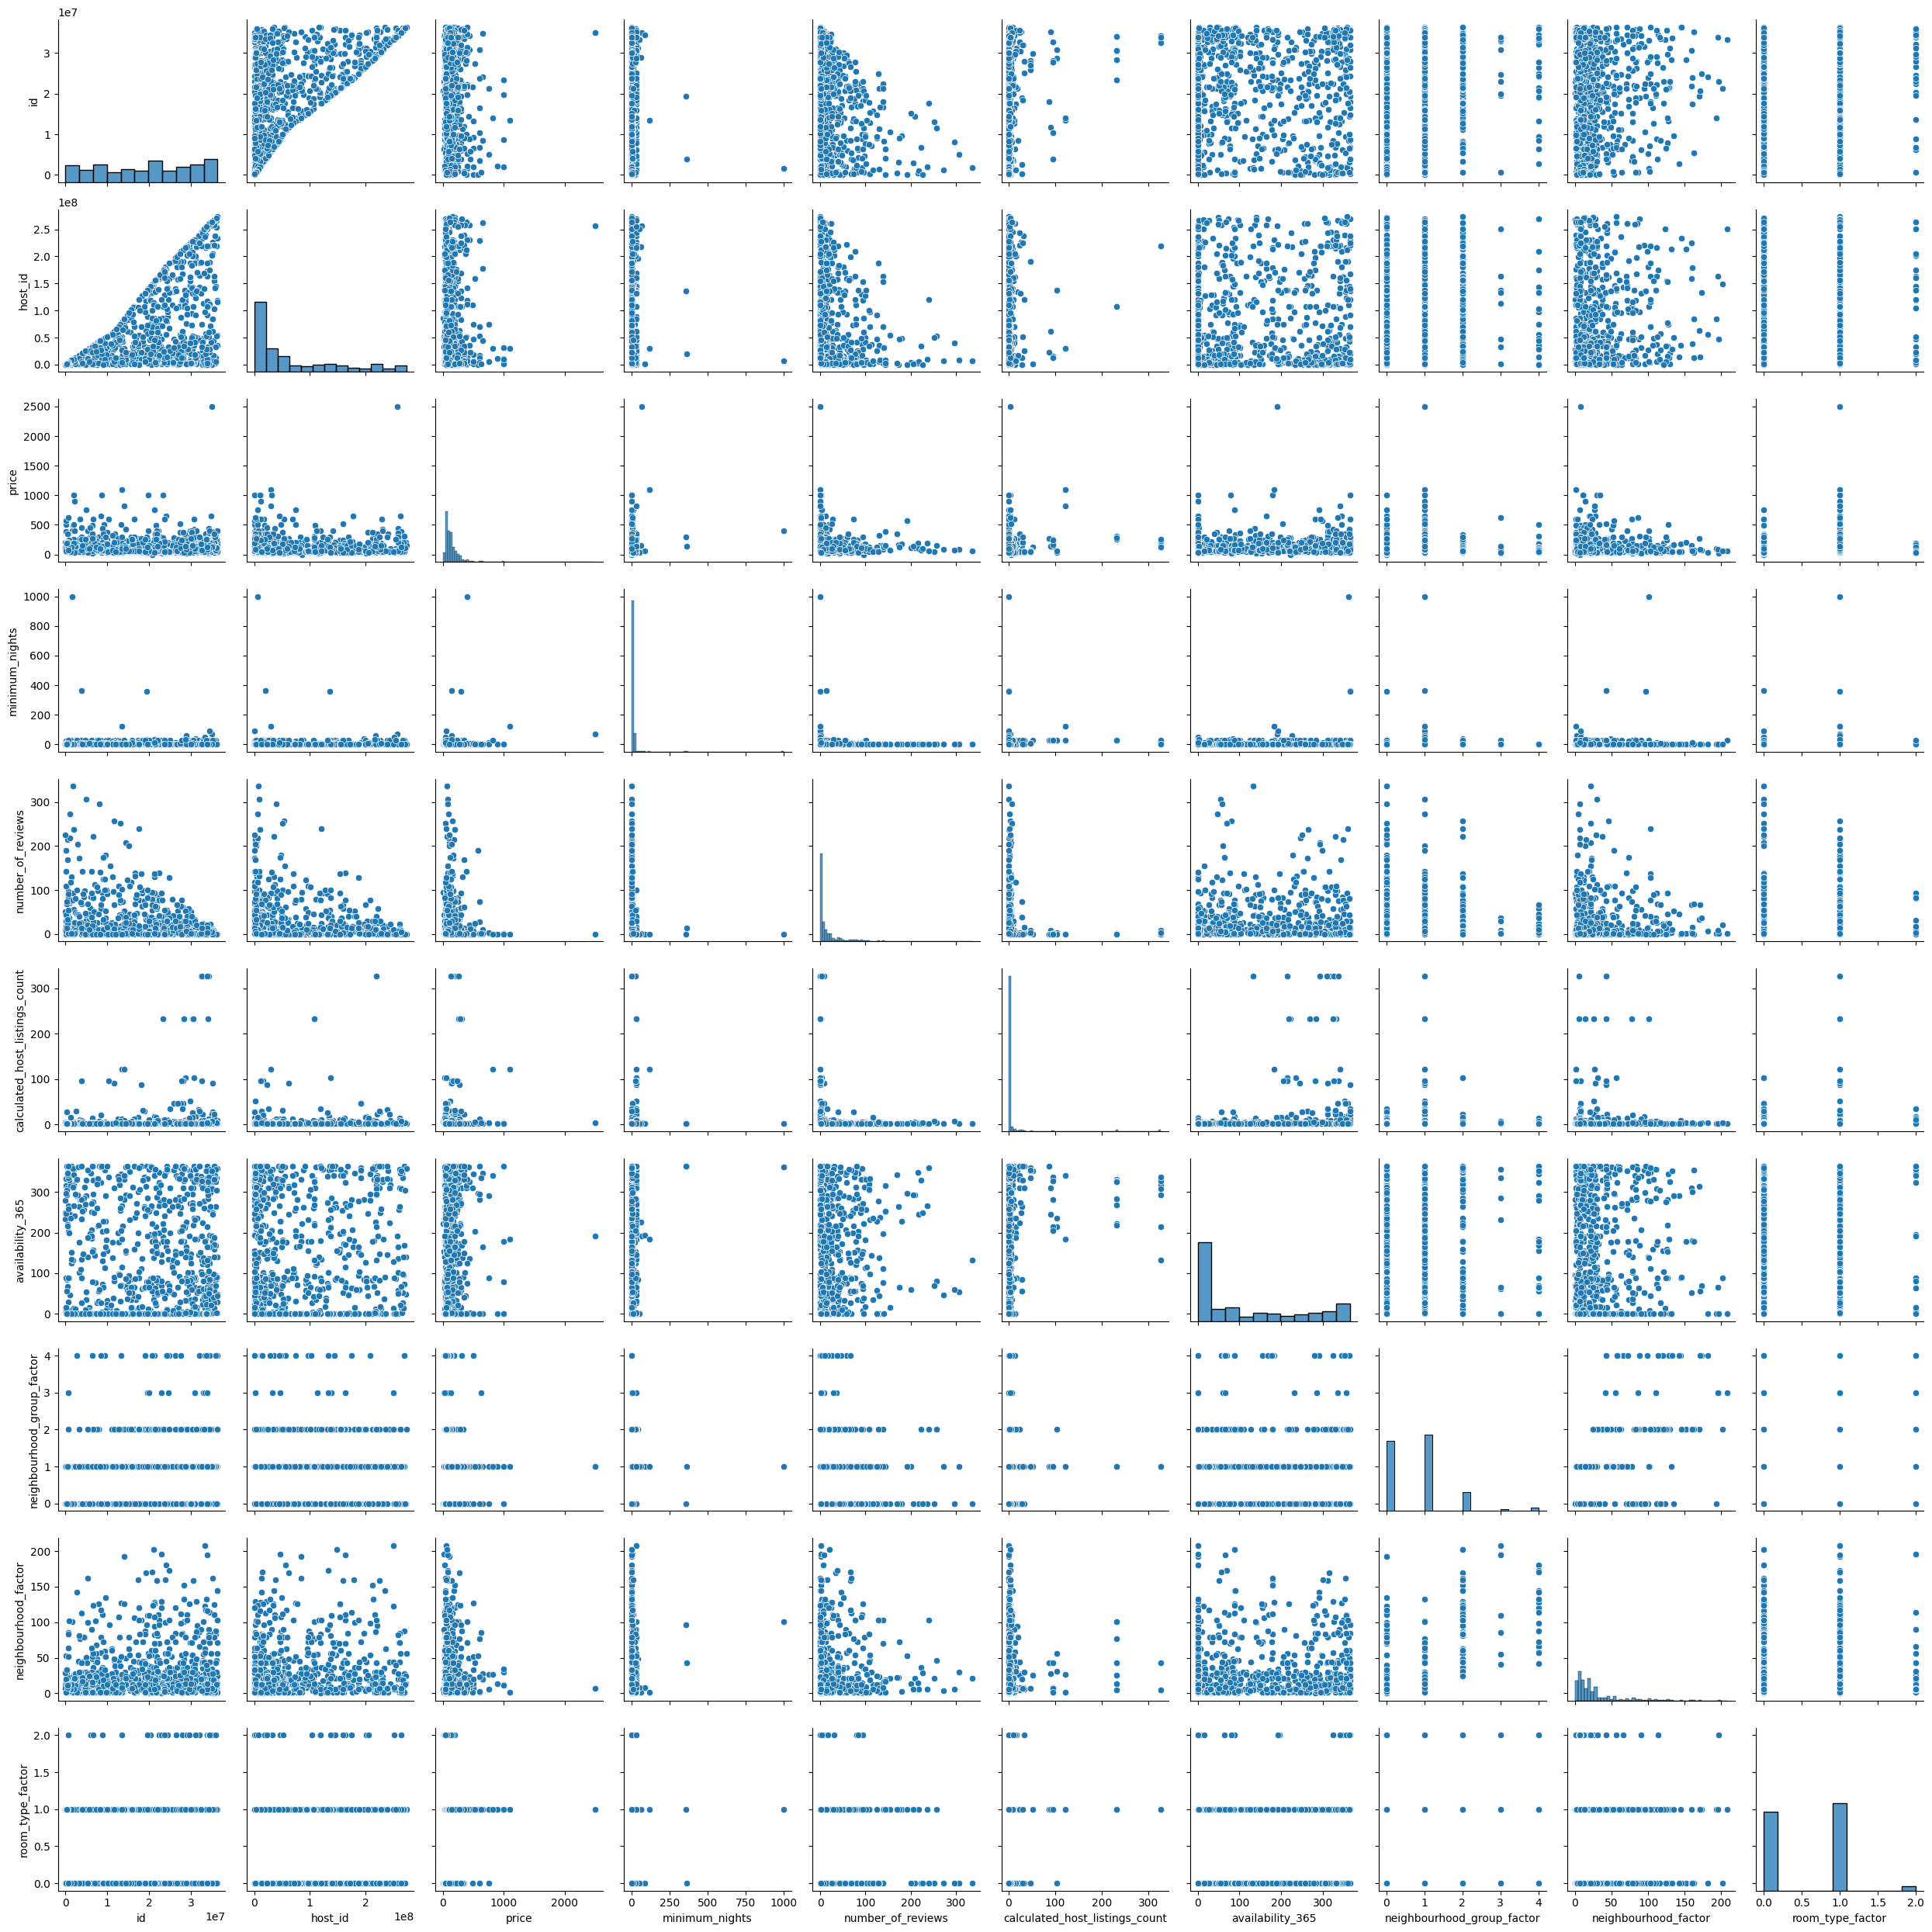

In [28]:
sns.pairplot(data=total_data.sample(1000))
plt.tight_layout()
plt.show()

**5. INGENIERÍA DE CARACTERÍSTICAS**

In [29]:
total_data.describe()

,id,host_id,price,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365,neighbourhood_group_factor,neighbourhood_factor,room_type_factor
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,152.720687,7.029962,23.274466,7.143982,112.781327,0.786911,29.888782,0.567113
std,1.098311e+07,7.861097e+07,240.154170,20.510550,44.550582,32.952519,131.622289,0.844386,34.676634,0.541249
min,2.539000e+03,2.438000e+03,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,9.471945e+06,7.822033e+06,69.000000,1.000000,1.000000,1.000000,0.000000,0.000000,7.500000,0.000000
50%,1.967728e+07,3.079382e+07,106.000000,3.000000,5.000000,1.000000,45.000000,1.000000,19.000000,1.000000
75%,2.915218e+07,1.074344e+08,175.000000,5.000000,24.000000,2.000000,227.000000,1.000000,37.000000,1.000000
max,3.648724e+07,2.743213e+08,10000.000000,1250.000000,629.000000,327.000000,365.000000,4.000000,220.000000,2.000000


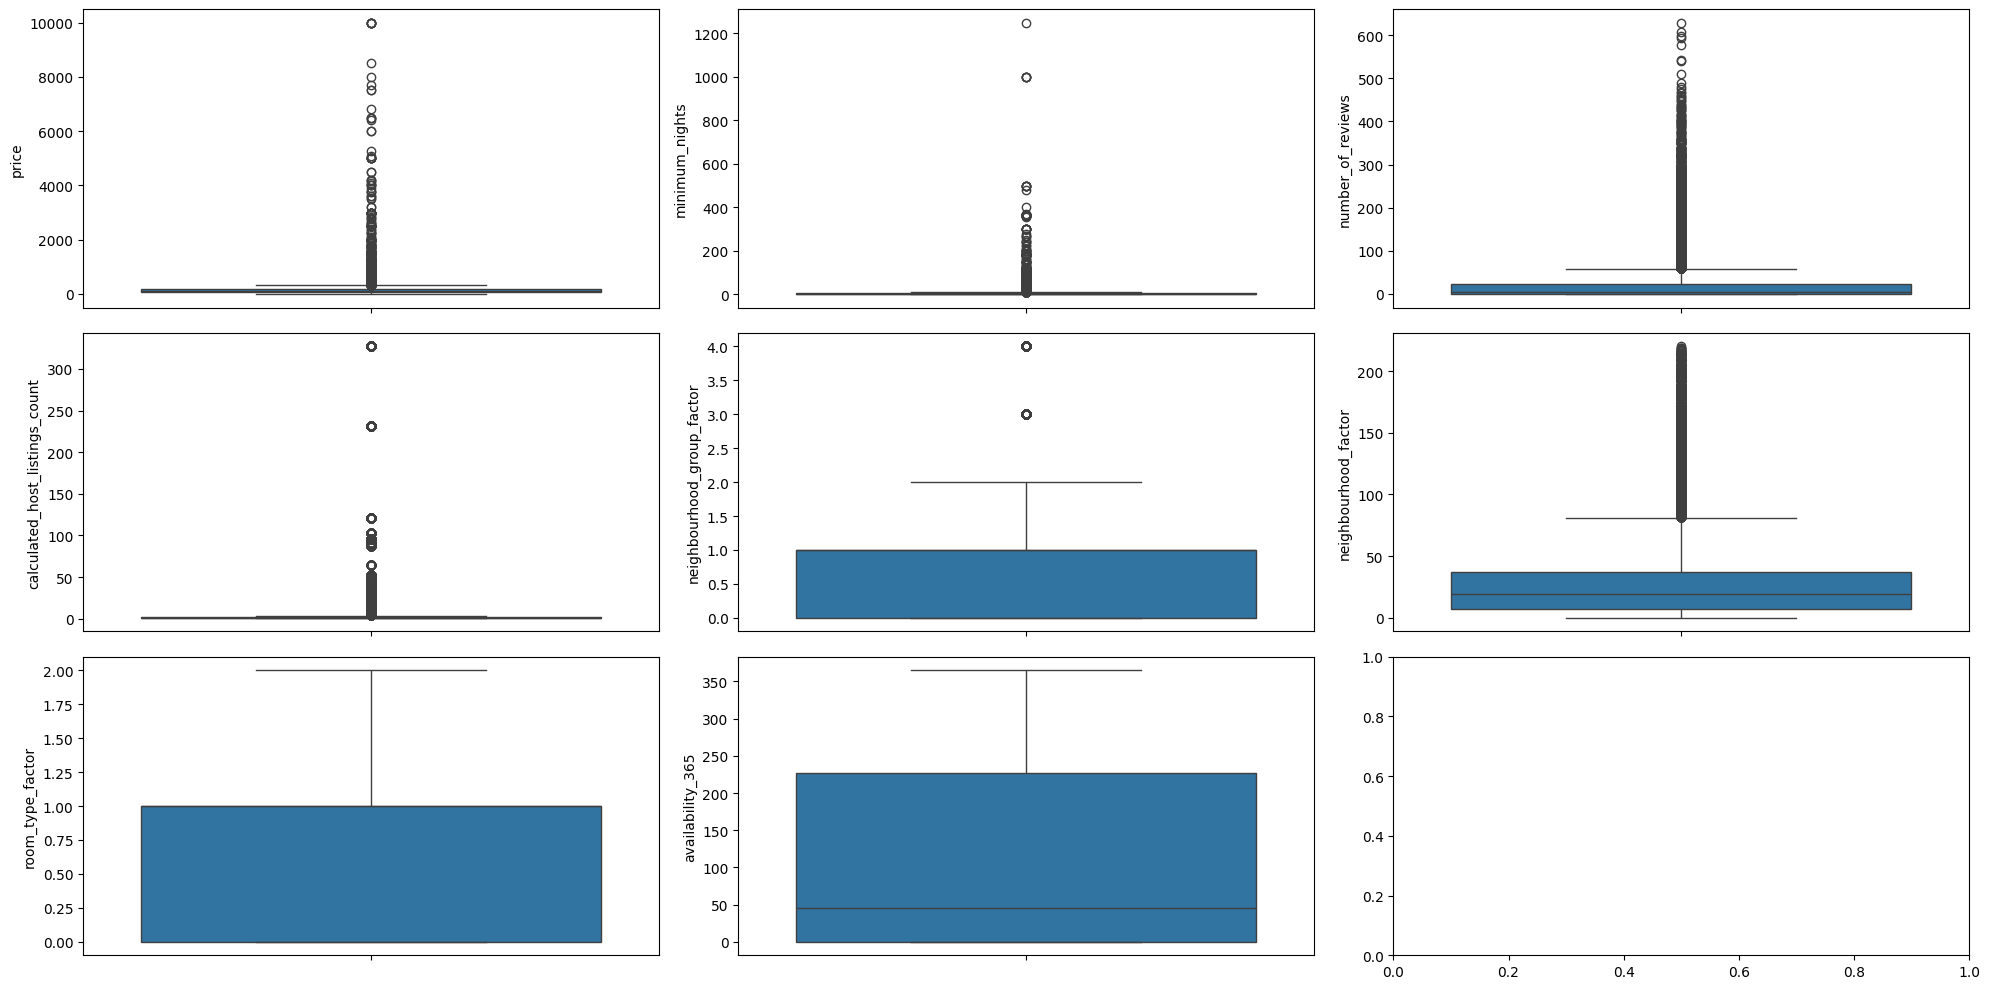

In [30]:
fig, axs = plt.subplots(3, 3, figsize=(20, 10))

sns.boxplot(ax=axs[0, 0], data=total_data, y="price")
sns.boxplot(ax=axs[0, 1], data=total_data, y="minimum_nights")
sns.boxplot(ax=axs[0, 2], data=total_data, y="number_of_reviews")
sns.boxplot(ax=axs[1, 0], data=total_data, y="calculated_host_listings_count")
sns.boxplot(ax=axs[1, 1], data=total_data, y="neighbourhood_group_factor")
sns.boxplot(ax=axs[1, 2], data=total_data, y="neighbourhood_factor")
sns.boxplot(ax=axs[2, 0], data=total_data, y="room_type_factor")
sns.boxplot(ax=axs[2, 1], data=total_data, y="availability_365")

plt.tight_layout()
plt.show()

In [31]:
# FUNCIÓN REUTILIZABLE PARA DETECTAR OUTLIERS
def detect_outliers_iqr(data, column_name):
    stats = data[column_name].describe()
    iqr = stats["75%"] - stats["25%"]
    upper_limit = stats["75%"] + 1.5 * iqr
    lower_limit = stats["25%"] - 1.5 * iqr
    outliers = data[(data[column_name] < lower_limit) | (data[column_name] > upper_limit)]

    print(f"\n{column_name.upper()}")
    print(f"  IQR: {iqr:.2f} | Límite inferior: {lower_limit:.2f} | Límite superior: {upper_limit:.2f}")
    print(f"  Outliers: {len(outliers)}")
    
    return outliers, lower_limit, upper_limit

numeric_cols = ['price', 'minimum_nights', 'number_of_reviews', 'calculated_host_listings_count']

for col in numeric_cols:
    detect_outliers_iqr(total_data, col)


PRICE
  IQR: 106.00 | Límite inferior: -90.00 | Límite superior: 334.00
  Outliers: 2972

MINIMUM_NIGHTS
  IQR: 4.00 | Límite inferior: -5.00 | Límite superior: 11.00
  Outliers: 6607

NUMBER_OF_REVIEWS
  IQR: 23.00 | Límite inferior: -33.50 | Límite superior: 58.50
  Outliers: 6021

CALCULATED_HOST_LISTINGS_COUNT
  IQR: 1.00 | Límite inferior: -0.50 | Límite superior: 3.50
  Outliers: 7081


In [32]:
# ELIMINO LOS OUTLIERS DE TODAS LAS VARIABLES NUMÉRICAS DE UNA SOLA VEZ
mask = pd.Series([True] * len(total_data), index=total_data.index)

for col in numeric_cols:
    outliers, lower, upper = detect_outliers_iqr(total_data, col)
    mask = mask & (total_data[col] >= lower) & (total_data[col] <= upper)

total_data = total_data[mask].reset_index(drop=True)

print(f"Dataset después de eliminar outliers: {total_data.shape}")


PRICE
  IQR: 106.00 | Límite inferior: -90.00 | Límite superior: 334.00
  Outliers: 2972

MINIMUM_NIGHTS
  IQR: 4.00 | Límite inferior: -5.00 | Límite superior: 11.00
  Outliers: 6607

NUMBER_OF_REVIEWS
  IQR: 23.00 | Límite inferior: -33.50 | Límite superior: 58.50
  Outliers: 6021

CALCULATED_HOST_LISTINGS_COUNT
  IQR: 1.00 | Límite inferior: -0.50 | Límite superior: 3.50
  Outliers: 7081
Dataset después de eliminar outliers: (31036, 13)


**Análisis de los valores faltantes**

In [33]:
total_data.isnull().sum().sort_values(ascending=False)

id                                0
host_id                           0
neighbourhood_group               0
neighbourhood                     0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
calculated_host_listings_count    0
availability_365                  0
neighbourhood_group_factor        0
neighbourhood_factor              0
room_type_factor                  0
dtype: int64

**6. TRAIN / TEST SPLIT**

In [34]:
variables = ['minimum_nights', 'number_of_reviews', 'calculated_host_listings_count',
            'neighbourhood_group_factor', 'neighbourhood_factor', 'room_type_factor', 'availability_365']

mi_x = total_data[variables]
mi_y = total_data["price"]

X_train, X_test, y_train, y_test = train_test_split(mi_x, mi_y, test_size=0.2, random_state=42)

**Escalado de valores (feature scaling)**

Las variables de identificación ('id' y 'host_id') se excluyeron del modelo, ya que no aportan información predictiva.

In [35]:
scaler = MinMaxScaler()

# FIT SOLO EN TRAIN
scaler.fit(X_train)

# Transform en train y test por separado
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [36]:
# Convertir a DataFrame
X_train_scaled = pd.DataFrame(X_train_scaled, columns=variables)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=variables)

**7. GUARDAR**

In [37]:
X_train_scaled.to_csv("../data/processed/train_processed.csv", index=False)
X_test_scaled.to_csv("../data/processed/test_processed.csv", index=False)

**8. CONCLUSIONES**

- El dataset inicial contenía 48895 filas y 16 columnas relacionadas con alquileres de Airbnb en Nueva York en 2019.
- El dataset después de eliminar outliers tiene 45796 filas y 13 columnas.
- Incluye variables de ubicación, precio, tipo de habitación, disponibilidad y reseñas.

**Variables eliminadas**
- Las variables 'last_review' y 'reviews_per_month' tenían muchos valores nulos. Para evitar problemas en el análisis, decidí eliminar esas columnas.
- Se eliminaron 'longitude' y 'latitude' porque, en este proyecto, no era necesario realizar un análisis de grupos geográficos.
- Las variables 'host_name' y 'name' se excluyeron porque no aportan información predictiva.

**Análisis numérico-numérico**
- No existe una relación fuerte entre el precio y el número mínimo de noches.
- No existe una relación fuerte entre el precio y el número de reseñas.

**Análisis categórico-categórico**
- Manhattan y Brooklyn concentran la mayor cantidad de alojamientos.
- Manhattan es el barrio con más sitios para alquilar. También es el barrio que tiene más viviendas completas ("entire home/apt").
- Manhattan presenta los precios más elevados.
- Brooklyn es el segundo barrio que más sitios tiene para alquilar. También es el barrio que tiene más habitaciones privadas.
- Staten Island tiene muy poca presencia en Airbnb.
- La mayoría de los alojamientos corresponden a viviendas completas o habitaciones privadas.
- Las viviendas completas presentan precios superiores.

**Matriz de correlación**
- Los anfitriones con más listings tienden a tener más disponibilidad. Además de eso, hay una correlación muy baja entre todos los datos.

**Feature scaling**
- Las variables de identificación ('id' y 'host_id') se excluyeron del modelo, ya que no aportan información predictiva.